In [1]:
from whar_datasets import (
    Loader,
    LOSOSplitter,
    PostProcessingPipeline,
    PreProcessingPipeline,
    WHARDatasetID,
    get_dataset_cfg,
)

2026-02-06 09:59:40,893 - whar-datasets - INFO - Running DownloadingStep
2026-02-06 09:59:40,894 - whar-datasets - INFO - Checking hash for DownloadingStep
2026-02-06 09:59:40,896 - whar-datasets - INFO - Hash is up to date
2026-02-06 09:59:40,896 - whar-datasets - INFO - Running ParsingStep
2026-02-06 09:59:40,896 - whar-datasets - INFO - Checking hash for ParsingStep
2026-02-06 09:59:40,899 - whar-datasets - INFO - Hash is up to date
2026-02-06 09:59:40,899 - whar-datasets - INFO - Running WindowingStep
2026-02-06 09:59:40,899 - whar-datasets - INFO - Checking hash for WindowingStep
2026-02-06 09:59:40,901 - whar-datasets - INFO - Hash is up to date
2026-02-06 09:59:40,901 - whar-datasets - INFO - Loading windowing
2026-02-06 09:59:40,911 - whar-datasets - INFO - activity_ids from 0 to 5
2026-02-06 09:59:40,912 - whar-datasets - INFO - subject_ids from 0 to 29
2026-02-06 09:59:40,963 - whar-datasets - INFO - Running SamplingStep
2026-02-06 09:59:40,964 - whar-datasets - INFO - Checki

73ac53772517a42c158fbcd2f956cc5e4a6bcdae69105cedd9f03556e85d3015
73ac53772517a42c158fbcd2f956cc5e4a6bcdae69105cedd9f03556e85d3015
fe29893e60e9e06d3354d086b5919383f0b4d928ba7c7fc3dfb792fc3aa9ebb4
fe29893e60e9e06d3354d086b5919383f0b4d928ba7c7fc3dfb792fc3aa9ebb4
9bfadd24724b0625f8ff36679a86ff7bf3a3ffd65d1884f120cb4e8b1e1500d3
9bfadd24724b0625f8ff36679a86ff7bf3a3ffd65d1884f120cb4e8b1e1500d3
13e895ff3fac19d2d57f8e31ea22211628fce03dbc40eda2e8a95e632a417f19
1bec483fad4d0435b51dc7602c604184bac728deb5a316546a61d8db199dfc10


2026-02-06 09:59:41,915 - whar-datasets - INFO - Computing samples
2026-02-06 09:59:41,915 - whar-datasets - INFO - Getting normalization parameters
2026-02-06 09:59:42,055 - whar-datasets - INFO - Normalizing and transforming windows (parallelized)


[########################################] | 100% Completed | 4.33 sms


2026-02-06 09:59:46,693 - whar-datasets - INFO - Saving samples
2026-02-06 09:59:46,787 - whar-datasets - INFO - Loading samples


num subjects / splits: 30/30
num channels: 9


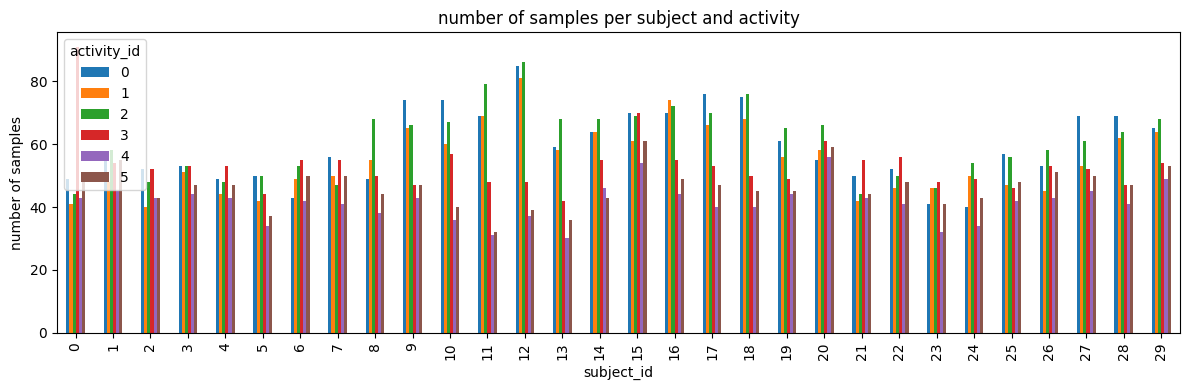

In [2]:
# create cfg for WISDM dataset
cfg = get_dataset_cfg(WHARDatasetID.UCI_HAR, "../datasets")
cfg.parallelize = True

# create and run pre-processing pipeline
pre_pipeline = PreProcessingPipeline(cfg)
activity_df, session_df, window_df = pre_pipeline.run()

# create LOSO splits
splitter = LOSOSplitter(cfg)
splits = splitter.get_splits(session_df, window_df)
split = splits[4]

# create and run post-processing pipeline for the specific split
post_pipeline = PostProcessingPipeline(
    cfg, pre_pipeline, window_df, split.train_indices
)
samples = post_pipeline.run()

# create dataloaders for the specific split
loader = Loader(session_df, window_df, post_pipeline.samples_dir, samples)

print(f"num subjects / splits: {cfg.num_of_subjects}/{len(splits)}")
print(f"num channels: {len(cfg.sensor_channels)}")

loader.plot_indices_statistics()

In [3]:
print(len(split.train_indices))
print(len(split.val_indices))
print(len(split.test_indices))

ya, ys, sample = loader.sample_items(1)

print(ya[0])
print(ys[0])
print(sample[0][0].shape)

7372
1843
284
1
5
(128, 9)


In [ ]:
import torch
from meta_learning.style.dual_head_trainer import DualHeadTrainer
from meta_learning.style.dual_head_set_classifier import DualHeadSetClassifier
from meta_learning.style.set_encoder import MeanSetEncoder
from meta_learning.models.tiny_har import TinyHAR

encoder = TinyHAR(
    input_channels=len(cfg.sensor_channels),
    window_size=int(cfg.window_time * cfg.sampling_freq),
    num_classes=cfg.num_of_activities,
    # num_filters=64,
)

set_encoder = MeanSetEncoder(
    encoder=encoder,
    feature_dim=128,
)

model = DualHeadSetClassifier(
    set_encoder=set_encoder,
    feature_dim=128,
    num_subjects=cfg.num_of_subjects,
    num_activities=len(cfg.activity_names),
)


optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss()
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")


trainer = DualHeadTrainer(
    loader=loader,
    split=split,
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    num_subjects=cfg.num_of_subjects,
    num_activities=len(cfg.activity_names),
    batch_size=32,
    context_size=5,
    kl_weight=0.5,
)

state_dict = trainer.fit(epochs=20, patience=5)

Starting Meta-Training on mps for 20 epochs.
Config: Shots per Class=10

Epoch 1/20


Meta-Train:   0%|          | 0/542 [00:00<?, ?it/s]

Meta-Val:   0%|          | 0/135 [00:00<?, ?it/s]

Meta-Test:   0%|          | 0/22 [00:00<?, ?it/s]

Train: Loss 0.4980 | Acc 0.8280 | F1 0.7414
Val:   Loss 0.3365 | Acc 0.8882 | F1 0.8418
Test:  Loss 0.1648 | Acc 0.9233 | F1 0.8850
>> Best model saved.

Epoch 2/20


...

Meta-Val:   0%|          | 0/135 [00:00<?, ?it/s]

Meta-Test:   0%|          | 0/22 [00:00<?, ?it/s]

Train: Loss 0.1539 | Acc 0.9517 | F1 0.9290
Val:   Loss 0.1574 | Acc 0.9509 | F1 0.9360
Test:  Loss 0.0820 | Acc 0.9716 | F1 0.9600
>> Best model saved.

Epoch 4/20


Meta-Train:   0%|          | 0/542 [00:00<?, ?it/s]

KeyboardInterrupt: 